In [15]:
import sqlite3
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from functools import wraps
from pathlib import Path #annotation follows def create_file() -> Path:
from typing import TextIO #annotation follows def open_file() -> TextIO:
from typing import IO #annotation follows def open_file() -> IO[str]:
from typing import Literal #annotation follows def output_name() -> Literal["file.txt"]:
from typing import List, Dict, Tuple

In [29]:
def descript(array1: pd.core.series.Series) -> List:
    """
    Function to describe the pandas object.
    """
    print("The type of data is:", type(array1))
    print("The number of methods are: ", len(dir(array1)))
    print("Its size is: ", array1.size)
    print("Its shape is: ", array1.shape)
    print("Its dimensions are: ", array1.ndim)
    if len(array1.index) > 10:
        print("The array holds ", len(array1.index), " indexes.")
        print("    of which the first 10 are:", array1.iloc[0:10].index)
    else:
        print("The array holds the indexes:", array1.index)
    try:
        array1.name
        print("Its names are: ", array1.name)
    except AttributeError as e:
        print(f"The series has no names assigned: {e}")
    print(f"\nSome Values are: {array1.head()}")
    

def minimalAnalyzer(var1: pd.core.frame.DataFrame, name: str) -> List:
    """
    Gives the flavors of the dataframe.
    """
    print(len(var1))
    try:
        if len(var1[name].unique()) > 15:
            print(f"Output is too large (more than {len(var1[name].unique())} values), printing the first ten: ")
            print(var1[name].unique()[0:10])
            print(var1[name].value_counts()[0:10])
        else:
            print(var1[name].unique())
            print(var1[name].value_counts())         
    except AttributeError as e:
        print(f"Unable to retrieve unique values as: {e}")

In [3]:
con = sqlite3.connect("tutorial.db")
cur = con.cursor()
cur.execute("CREATE TABLE Ages (name VARCHAR(128), age INTEGER)")
con.close()

OperationalError: table Ages already exists

In [116]:
con.close()

In [4]:
data = [
    ('Kahlea', 35),
    ('Stacey', 28),
    ('Rio', 18),
    ('Wesley', 25),    
]

cur.executemany("INSERT INTO Ages VALUES(?, ?)", data)

In [5]:
con.commit()

In [7]:
pan = cur.execute("SELECT hex(name || age) AS X FROM Ages ORDER BY X")

In [8]:
pan.fetchone()

('4B61686C65613335',)

In [9]:
con.close()


In [10]:
from export_db import export_db_to_sqlite

export_db_to_sqlite("tutorial.db", "tutorial.sqlite")

Export completed: 'tutorial.db' → 'tutorial.sqlite'


True

In [11]:
conn = sqlite3.connect('emaildb.sqlite')
cur = conn.cursor()

cur.execute('DROP TABLE IF EXISTS Counts')

cur.execute('''
CREATE TABLE Counts (org TEXT, count INTEGER)''')

fname = input('Enter file name: ')
if (len(fname) < 1): fname = 'mbox-short.txt'
fh = open(fname)
for line in fh:
    if not line.startswith('From: '): continue
    pieces = line.split()
    email = pieces[1]
    cur.execute('SELECT count FROM Counts WHERE email = ? ', (email,))
    row = cur.fetchone()
    if row is None:
        cur.execute('''INSERT INTO Counts (email, count)
                VALUES (?, 1)''', (email,))
    else:
        cur.execute('UPDATE Counts SET count = count + 1 WHERE email = ?',
                    (email,))
    conn.commit()

# https://www.sqlite.org/lang_select.html
sqlstr = 'SELECT email, count FROM Counts ORDER BY count DESC LIMIT 10'

for row in cur.execute(sqlstr):
    print(str(row[0]), row[1])

cur.close()

Enter file name:  mbox-short.txt


zqian@umich.edu 195
mmmay@indiana.edu 161
cwen@iupui.edu 158
chmaurer@iupui.edu 111
aaronz@vt.edu 110
ian@caret.cam.ac.uk 96
jimeng@umich.edu 93
rjlowe@iupui.edu 90
dlhaines@umich.edu 84
david.horwitz@uct.ac.za 67


In [95]:
195 + 161 + 158 + 111 + 110 + 96 + 93 + 90 + 84 + 67

1165

In [4]:

def read_File(fh):
    newvar = fh.split('\n')
    return newvar
#def 
        
def each_email(text):
    pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails = re.findall(pattern, text)
    return emails

def each_domain(text):
    pattern = r'@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    domain = re.findall(pattern, text)
    return domain

#def 

text = """Ross McFluff: 834.345.1254 155 Elm Street

Ronald Heathmore: 892.345.3428 436 Finley Avenue
Frank Burger: 925.541.7625 662 South Dogwood Way


Helga Fritz: 852.961.4531 772 North Lussine Place

+

Heather Albrecht: 548.326.4584 919 Park Place"""

entries = re.split("\n+\W", text)
entries
    



['Ross McFluff: 834.345.1254 155 Elm Street',
 'Ronald Heathmore: 892.345.3428 436 Finley Avenue\nFrank Burger: 925.541.7625 662 South Dogwood Way',
 'Helga Fritz: 852.961.4531 772 North Lussine Place',
 '',
 'Heather Albrecht: 548.326.4584 919 Park Place']

In [5]:
#file = r".\mbox-short.txt"
file = r".\mbox-short.txt"
try:
    with open(file, "r", encoding="UTF-8") as fl:
        content = fl.read()
        #print(type(content))
        #pieces = read_File(content)
        emails = each_email(content)
        #print(pieces)
        print(len(emails))
        
        
except FileNotFoundError:
    print("El archivo no existe.")
except Exception as e:
    print("Error al leer el archivo:", e)

20140


In [6]:
emails[10:15]

['stephen.marquard@uct.ac.za',
 'louis@media.berkeley.edu',
 'postmaster@collab.sakaiproject.org',
 '200801042308.m04N8v6O008125@nakamura.uits.iupui.edu',
 'source@collab.sakaiproject.org']

In [7]:

datadic = {"emails":emails}

def create_dataframe(value1):
    try:
        df_from_dict = pd.DataFrame(data=value1)
        return df_from_dict
    except Exception as e:
        print(f"Error creating DataFrame: {e}")
        
df_emails = create_dataframe(datadic)

In [30]:
descript(df_emails)
minimalAnalyzer(df_emails, 'emails')

The type of data is: <class 'pandas.core.frame.DataFrame'>
The number of methods are:  441
Its size is:  20140
Its shape is:  (20140, 1)
Its dimensions are:  2
The array holds  20140  indexes.
    of which the first 10 are: RangeIndex(start=0, stop=10, step=1)
The series has no names assigned: 'DataFrame' object has no attribute 'name'

Some Values are:                                               emails
0                         stephen.marquard@uct.ac.za
1                 postmaster@collab.sakaiproject.org
2  200801051412.m05ECIaH010327@nakamura.uits.iupu...
3                     source@collab.sakaiproject.org
4                     source@collab.sakaiproject.org
20140
Output is too large (more than 1851 values), printing the first ten: 
['stephen.marquard@uct.ac.za' 'postmaster@collab.sakaiproject.org'
 '200801051412.m05ECIaH010327@nakamura.uits.iupui.edu'
 'source@collab.sakaiproject.org' 'louis@media.berkeley.edu'
 '200801042308.m04N8v6O008125@nakamura.uits.iupui.edu' 'zqian@umich

In [13]:
flavors = df_emails["emails"].value_counts()

In [24]:
bflav = flavors.tolist()

In [41]:
bflav[75:80]
xhorizontalAx = np.arange(0, len(bflav), 1)
print(len(bflav))
print(len(xhorizontalAx))

1851
1851


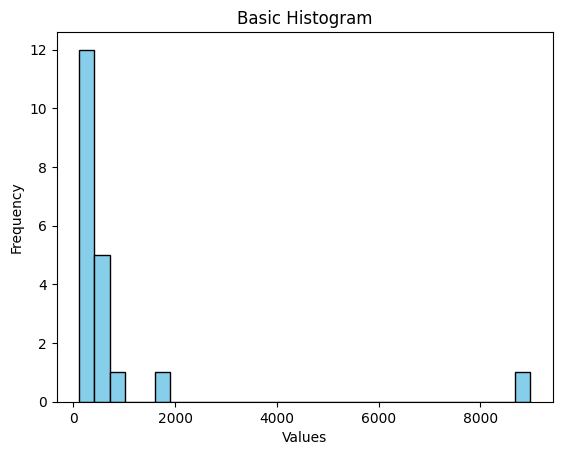

In [33]:
plt.hist(bflav[0:20], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')
plt.show()

The histogram is not a good idea because it doesn't show the correct categories in the horizontal axis. A series from 1 to the length of the list should be more appropriate.

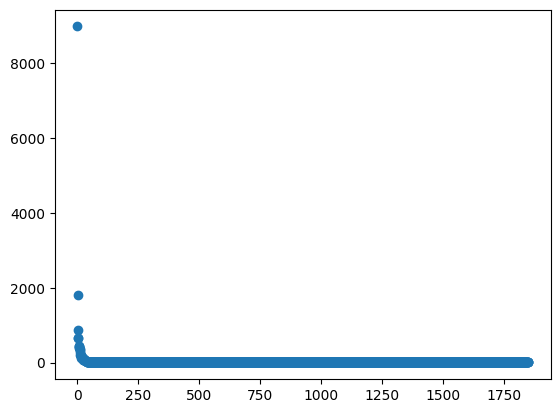

In [42]:
plt.scatter(xhorizontalAx, bflav)
plt.show()

In [53]:
flavors.iloc[0:10]

emails
source@collab.sakaiproject.org        8985
postmaster@collab.sakaiproject.org    1797
zqian@umich.edu                        877
cwen@iupui.edu                         655
mmmay@indiana.edu                      644
chmaurer@iupui.edu                     448
aaronz@vt.edu                          442
ian@caret.cam.ac.uk                    422
jimeng@umich.edu                       389
rjlowe@iupui.edu                       373
Name: count, dtype: int64

In [81]:
descript(flavors)

The type of data is: <class 'pandas.core.series.Series'>
The number of methods are:  419
It's size is:  1851
It's shape is:  (1851,)
It's dimensions are:  1
The array holds  1851  indexes.
    of which the first 10 are: Index(['source@collab.sakaiproject.org', 'postmaster@collab.sakaiproject.org',
       'zqian@umich.edu', 'cwen@iupui.edu', 'mmmay@indiana.edu',
       'chmaurer@iupui.edu', 'aaronz@vt.edu', 'ian@caret.cam.ac.uk',
       'jimeng@umich.edu', 'rjlowe@iupui.edu'],
      dtype='object', name='emails')
It's names are:  count


In [66]:
r = np.array([1, 2])
ser = pd.Series(r, copy=False)

In [82]:
descript(ser)

The type of data is: <class 'pandas.core.series.Series'>
The number of methods are:  419
It's size is:  2
It's shape is:  (2,)
It's dimensions are:  1
The array holds the indexes: RangeIndex(start=0, stop=2, step=1)
It's names are:  None


In [85]:
ser[1] == ser.iloc[1]

np.True_

In [87]:
if not hasattr(flavors.iloc[:].to_list(), '__iter__') or not hasattr(flavors.index.to_list(), '__iter__'):
    raise TypeError("Both inputs must be iterable.")
paired_list = list(zip(flavors.index.to_list(), flavors.iloc[:].to_list()))

In [88]:
paired_list[0:10]

[('source@collab.sakaiproject.org', 8985),
 ('postmaster@collab.sakaiproject.org', 1797),
 ('zqian@umich.edu', 877),
 ('cwen@iupui.edu', 655),
 ('mmmay@indiana.edu', 644),
 ('chmaurer@iupui.edu', 448),
 ('aaronz@vt.edu', 442),
 ('ian@caret.cam.ac.uk', 422),
 ('jimeng@umich.edu', 389),
 ('rjlowe@iupui.edu', 373)]

In [92]:
with open(r".\add_traling_comma.py", "w", encoding="utf-8") as file:
    file.write(str(paired_list))

In [100]:
from add_traling_comma import file
var_emails_to_add = file()
conn = sqlite3.connect('dabase.sqlite')
cur = conn.cursor()
cur.execute("CREATE TABLE Counts (org TEXT, count INTEGER)")
cur.executemany("INSERT INTO Counts VALUES(?, ?)", var_emails_to_add)
conn.commit()
conn.close()

In [101]:
conn.close()

In [115]:
#from archive import function
#var_emails_to_add = function()

def databaseUpdate(ConnectionName, var_tuple):
    try:
        conn = sqlite3.connect(ConnectionName)
        cur = conn.cursor()
        cur.execute("CREATE TABLE Counts (org TEXT, count INTEGER)")
        cur.executemany("INSERT INTO Counts VALUES(?, ?)", var_tuple)
        conn.commit()
        conn.close()
    except OperationalError:
        print("Are you sure you want to insert a new table?")
    else:
        print("The execution finished.")


In [ ]:
from archive import function
var_emails_to_add = function()

In [106]:
#conn = sqlite3.connect('amiga.sqlite')
cur = conn.cursor()
#cur.execute("CREATE TABLE Counts (org TEXT, count INTEGER)")
data = [("Omega", 9), ("Alpha", 9), ("Jokel", 8), ("Glad", 8), ("Nukle", 8), ("Vlad", 5), ("Dokey", 5), ("Jake", 4),
]
cur.executemany("INSERT INTO Counts VALUES(?, ?)", data)
conn.commit()
conn.close()

In [108]:
conn = sqlite3.connect('amiga.sqlite')

In [112]:
conn.close()

In [109]:
bogus = sqlite3.connect('amiga.sqlite')

In [111]:
bogus.close()

In [110]:
jade = sqlite3.connect('jokel.sqlite')

In [113]:
jade.close()

In [54]:
df_domain = df_emails["emails"].unique()
df_domain = list(map(each_domain, df_domain))

In [60]:
print(df_domain[0:10])
domaindic = {"domains":df_domain}
dfdomains = create_dataframe(domaindic)
dfdomains.head()
df_newdomain = pd.Series(df_domain)
dfcast_domain = pd.DataFrame("domain":df_newdomain)

[['@uct.ac.za'], ['@collab.sakaiproject.org'], ['@nakamura.uits.iupui.edu'], ['@collab.sakaiproject.org'], ['@media.berkeley.edu'], ['@nakamura.uits.iupui.edu'], ['@umich.edu'], ['@nakamura.uits.iupui.edu'], ['@iupui.edu'], ['@nakamura.uits.iupui.edu']]


In [66]:
#len(dfdomains["domains"].unique())
print(type(dfdomains["domains"]))

<class 'pandas.core.series.Series'>


In [70]:
print(df_newdomain.head())
print(type(df_newdomain[0]))

0                  [@uct.ac.za]
1    [@collab.sakaiproject.org]
2    [@nakamura.uits.iupui.edu]
3    [@collab.sakaiproject.org]
4         [@media.berkeley.edu]
dtype: object
<class 'list'>


In [71]:
def elimPar(value1):
    return value1[0].strip("[]")

honestdomain = list(map(elimPar, df_newdomain))

In [74]:
print(len(honestdomain))
print(type(honestdomain))
print(type(honestdomain[0]))

1851
<class 'list'>
<class 'str'>


In [75]:
domaindic = {"domains":honestdomain}
new_2dfdomains = create_dataframe(domaindic)

In [81]:
print(type(new_2dfdomains))
print(len(new_2dfdomains))

<class 'pandas.core.frame.DataFrame'>
1851


In [76]:
above_ = titanic[titanic["Age"] > 35]

pandas.core.frame.DataFrame

In [80]:
len(new_2dfdomains["domains"].unique())

25

In [86]:
type(new_2dfdomains["domains"].value_counts())

pandas.core.series.Series

In [88]:
len(new_2dfdomains["domains"].value_counts())

25

In [94]:
new_2dfdomains["domains"].value_counts()[:10]

domains
@nakamura.uits.iupui.edu    1797
@umich.edu                    11
@iupui.edu                    10
@indiana.edu                   5
@caret.cam.ac.uk               3
@media.berkeley.edu            3
@uct.ac.za                     2
@collab.sakaiproject.org       2
@rsmart.com                    2
@gmail.com                     1
Name: count, dtype: int64

In [87]:
new_2dfdomains["domains"].value_counts()

domains
@nakamura.uits.iupui.edu    1797
@umich.edu                    11
@iupui.edu                    10
@indiana.edu                   5
@caret.cam.ac.uk               3
@media.berkeley.edu            3
@uct.ac.za                     2
@collab.sakaiproject.org       2
@rsmart.com                    2
@gmail.com                     1
@et.gatech.edu                 1
@bu.edu                        1
@asu.edu                       1
@vt.edu                        1
@lancaster.ac.uk               1
@ucdavis.edu                   1
@ufp.pt                        1
@txstate.edu                   1
@stanford.edu                  1
@whitman.edu                   1
@fhda.edu                      1
@unicon.net                    1
@loi.nl                        1
@utoronto.ca                   1
@berkeley.edu                  1
Name: count, dtype: int64

In [2]:
def timethis(func):
    '''
    Decorator that reports the execution time.
    '''
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(func.__name__, end-start)
        return result
    return wrapper
    

In [9]:
@timethis
def countdown(n):
    '''
    count this
    '''
    while n > 0:
        n -= 1
    return n

In [12]:
alf = countdown(10000)

countdown 0.0009958744049072266


In [13]:
alf

0

In [ ]:
def timethis(func):
    '''
    Decorator that reports the execution time.
    '''
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(func.__name__, end-start)
        return result
    return wrapper
    

In [15]:

#Prototyping the function
"""
def greetHuman(Names):
    '''
    greet to humans
    '''
    print("Hello people from Earth! ", Names)
"""

def addnonHumanGreet(func):
    '''
    Decorator that reports the execution time.
    '''
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(func.__name__, end-start)
        print("Hi there amazing humanzz!")
        return result
    return wrapper

@addnonHumanGreet
def greetHuman(Names):
    '''
    greet to humans
    '''
    print("Hello people from Earth! ", Names)

In [16]:
greetHuman("Amiko")

Hello people from Earth!  Amiko
greetHuman 0.0019876956939697266
Hi there amazing humanzz!


In [5]:
file = "mbox-short.txt"
with open(file, "r", encoding="UTF-8") as fl:
        content = fl.read()
        type(content)

TypeError: 'str' object cannot be interpreted as an integer

In [ ]:
for i in [108, 105, 115, 116]:
    print(f"{i}: {chr(i)}")



In [ ]:
plt.hist(data, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')
plt.show()

In [ ]:
def databaseUpdate(ConnectionName, var_tuple):
    try:
        conn = sqlite3.connect(ConnectionName)
        cur = conn.cursor()
        cur.execute("CREATE TABLE Counts (org TEXT, count INTEGER)")
        cur.executemany("INSERT INTO Counts VALUES(?, ?)", var_tuple)
        conn.commit()
        conn.close()
    except OperationalError:
        print("Are you sure you want to insert a new table?")
    else:
        print("The execution finished.")




In [ ]:
qqq = "({0[]}".format()

## References
+ https://docs.python.org/3/library/string.html
+ https://docs.python.org/3/library/stdtypes.html#str.split
+ https://docs.python.org/3/library/re.html#search-vs-match
+ https://regexbox.com/cheatsheet
+ https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html
+ https://pandas.pydata.org/docs/reference/api/pandas.Categorical.map.html#pandas.Categorical.map
+ https://pandas.pydata.org/docs/user_guide/dsintro.html
+ https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html
+ https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.iloc.html
+ https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html
+ https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.loc.html#pandas.Series.loc
+ https://pandas.pydata.org/pandas-docs/stable/reference/series.html
+ https://docs.python.org/3/tutorial/errors.html

__Search for__ :

+ with open file python
+ python regex for mails
+ create pandas frame
+ pandas levels or unique values
+ create pandas dataframe from numpy
+ sapply python
+ exit node console
+ create a list of tuples with zip python
+ adding trailing comma to list python
+ how to automatically add trailing commas to all multi-line lists in your Python code using a formatter like Black.
+ with open python receips